In [1]:
from google.colab import files
uploaded = files.upload()  # select your Dataset.csv

Saving dataset.csv.csv to dataset.csv.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("dataset.csv.csv")  # use your actual filename
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
df['Aggregate rating'].describe()

,Aggregate rating
count,9551.000000
mean,2.666370
std,1.516378
min,0.000000
25%,2.500000
50%,3.200000
75%,3.700000
max,4.900000


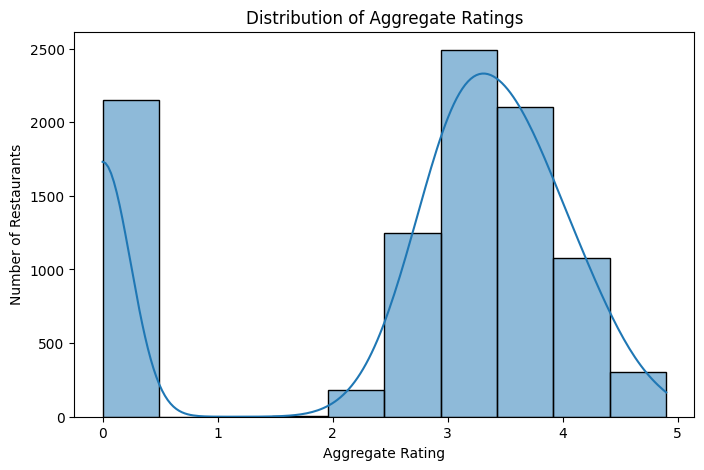

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=10, kde=True)
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.show()

In [8]:
# Create rating range bins
bins = [0, 1, 2, 3, 3.5, 4, 4.5, 5]
labels = ['0-1', '1-2', '2-3', '3-3.5', '3.5-4', '4-4.5', '4.5-5']
df['Rating Range'] = pd.cut(df['Aggregate rating'], bins=bins, labels=labels, include_lowest=True)

rating_counts = df['Rating Range'].value_counts().sort_index()
print(rating_counts)

most_common_range = rating_counts.idxmax()
print(f"Most common rating range: {most_common_range}")

Rating Range
0-1      2148
1-2        10
2-3      1891
3-3.5    2502
3.5-4    1886
4-4.5     908
4.5-5     206
Name: count, dtype: int64
Most common rating range: 3-3.5


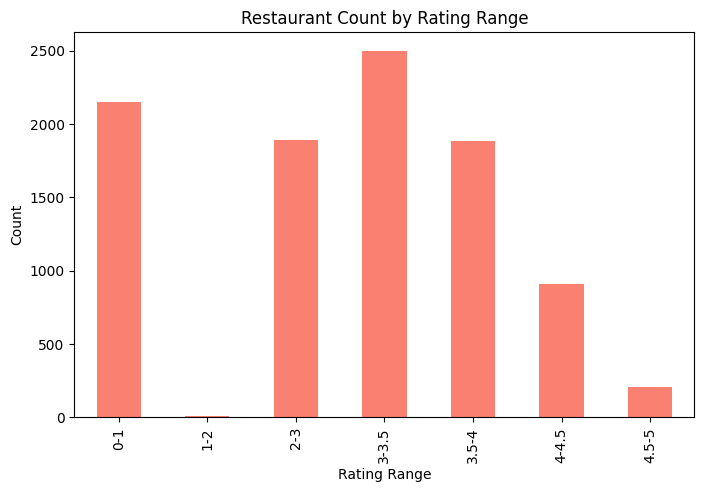

In [9]:
plt.figure(figsize=(8,5))
rating_counts.plot(kind='bar', color='salmon')
plt.title('Restaurant Count by Rating Range')
plt.xlabel('Rating Range')
plt.ylabel('Count')
plt.show()

In [10]:
average_votes = df['Votes'].mean()
print(f"Average number of votes received by restaurants: {average_votes:.2f}")

Average number of votes received by restaurants: 156.91


In [11]:
print("Summary:")
print(f"- Most common rating range: {most_common_range}")
print(f"- Average votes per restaurant: {average_votes:.2f}")

Summary:
- Most common rating range: 3-3.5
- Average votes per restaurant: 156.91
